# Closed-Loop Berthing Guidance

## tl;dr

This notebook demonstrates the central loop: **plan → observe → predict → compare → recommend → move → observe again**. A fixed berth and nominal path are known in advance. The system ranks a small set of abstract corrective actions; a human operator retains authority.

> **Simulation only.** Thresholds, dynamics, and actions are educational abstractions—not certified navigation limits or real helm commands.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
ASSETS = ROOT / "assets"
ASSETS.mkdir(exist_ok=True)

from src.simulator import DT_SECONDS, VesselState, generate_environment_series
from src.trajectory import generate_nominal_trajectory
from src.recommender import (
    CANDIDATE_ACTIONS, classify_deviation, closed_loop_metrics,
    recommend_action, recommendation_reason, run_closed_loop,
)

COLORS = {"plan": "#243B53", "baseline": "#D97706", "loop": "#146C94", "berth": "#7C3AED"}
plt.rcParams.update({
    "figure.figsize": (10, 5), "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.22, "font.size": 10,
})
trajectory = generate_nominal_trajectory()
berth = pd.read_csv(ROOT / "data/sample/berth.csv").iloc[0]

## 1. Closed-Loop Guidance Problem

The planner defines where the vessel should go. The predictor estimates where it will go next. The deviation detector measures divergence. The recommender asks which abstract action is expected to reduce that divergence while preserving progress. The result is advisory; the pilot or bridge crew accepts or overrides it.

## 2. Planned Trajectory

In [2]:
display(trajectory.iloc[::max(1, len(trajectory)//8)][
    ["x", "y", "desired_heading_deg", "desired_speed_mps", "along_track_progress"]
].round(2))
display(pd.DataFrame([berth]))

,x,y,desired_heading_deg,desired_speed_mps,along_track_progress
0,-900.00,-340.00,61.63,5.00,0.00
25,-792.24,-281.81,61.63,4.83,0.13
50,-684.48,-223.62,61.63,4.66,0.25
75,-575.44,-169.21,64.36,4.36,0.38
100,-465.79,-116.58,64.36,4.01,0.50
125,-353.19,-71.60,74.02,3.52,0.63
150,-236.17,-38.09,74.02,2.83,0.75
175,-116.76,-14.27,83.03,1.90,0.88


,berth_id,target_x,target_y,target_heading_deg,approach_zone_radius_m
0,BERTH_FIXED_01,0.0,0.0,90.0,45.0


## 3. Deviation Metrics

- **Cross-track error:** signed lateral distance from the nominal path.
- **Heading error:** shortest signed difference between vessel and desired headings.
- **Speed error:** vessel speed minus the local desired speed profile.
- **Distance to berth:** Euclidean distance to the fixed target.

Demonstration states are `ON_TRACK` (≤8 m cross-track and ≤6° heading error), `MINOR_DEVIATION` (≤25 m and ≤15°), otherwise `MAJOR_DEVIATION`. These are synthetic interpretation bands only.

## 4. Action Candidates and Scoring

In [3]:
display(pd.DataFrame({"abstract_action": CANDIDATE_ACTIONS}))

,abstract_action
0,MAINTAIN
1,CORRECT_PORT
2,CORRECT_STARBOARD
3,REDUCE_SPEED
4,INCREASE_SPEED
5,STABILIZE


Each candidate is rolled forward for six 2-second steps. The transparent cost is:

`1.80 × |cross-track error| + 0.10 × |heading error| + 2.20 × |speed error| + 0.75 × lack of progress + action-change penalty`

Weights are deliberately simple and were not optimized. The look-ahead uses the simulator, not reinforcement learning or autonomous continuous control.

## 5. One-Step Recommendation Example

In [4]:
example_state = VesselState(x=-455.0, y=-52.0, heading_deg=68.0, speed_mps=3.9, yaw_rate_deg_s=0.0)
example_environment = generate_environment_series("crosswind", 1, seed=84).iloc[0]
example_action, example_ranking = recommend_action(
    example_state, example_environment, trajectory, berth, previous_action="MAINTAIN"
)
display(example_ranking.round(2))
display(Markdown(f"**Recommendation: {example_action}**  \n{recommendation_reason(example_ranking)}"))

,action,cost,cross_track_error_m,heading_error_deg,speed_error_mps,progress_m,action_change_penalty
0,CORRECT_STARBOARD,98.57,54.09,2.28,0.13,46.34,0.7
1,MAINTAIN,104.80,57.73,-6.02,0.13,45.40,0.0
2,STABILIZE,105.42,57.38,-6.02,-0.38,42.21,0.7
3,REDUCE_SPEED,106.16,56.76,-6.02,-1.22,36.61,0.7
4,INCREASE_SPEED,108.94,58.44,-6.02,1.12,51.79,0.7
5,CORRECT_PORT,112.82,61.34,-14.32,0.13,44.08,0.7


**Recommendation: CORRECT_STARBOARD**  
CORRECT_STARBOARD has the lowest short-horizon cost (98.57); expected |cross-track error| is 54.1 m with 46.3 m progress toward the fixed berth.

## 6. Full Closed-Loop Simulation

In [5]:
SCENARIOS = ["calm", "crosswind", "changing_wind_current"]
runs = {}
metric_rows = []
for scenario in SCENARIOS:
    for use_recommendations in (False, True):
        key = (scenario, "Recommendation loop" if use_recommendations else "No correction")
        run = run_closed_loop(scenario, trajectory, berth, use_recommendations, seed=84)
        runs[key] = run
        metric_rows.append(closed_loop_metrics(run, berth))

metrics = pd.DataFrame(metric_rows)
display(metrics.round(2))

,scenario,controller,mean_cross_track_error_m,max_cross_track_error_m,p95_cross_track_error_m,final_position_error_m,final_heading_error_deg,time_to_approach_zone_s,corrective_recommendations,on_track_pct,major_deviation_pct,reached_approach_zone
0,calm,No correction,108.05,347.99,319.36,619.33,28.01,NaN,0,28.67,60.00,False
1,calm,Recommendation loop,0.86,2.13,1.87,44.55,3.25,258.0,63,100.00,0.00,True
2,crosswind,No correction,169.40,474.61,440.24,695.36,28.01,NaN,0,9.33,77.33,False
3,crosswind,Recommendation loop,1.17,1.97,1.84,40.90,3.68,208.0,32,56.19,0.00,True
4,changing_wind_current,No correction,198.93,530.73,493.28,698.21,28.01,NaN,0,5.33,85.33,False
5,changing_wind_current,Recommendation loop,1.00,2.28,2.02,39.88,3.72,210.0,33,10.38,0.00,True


## 7. Trajectory Visualization

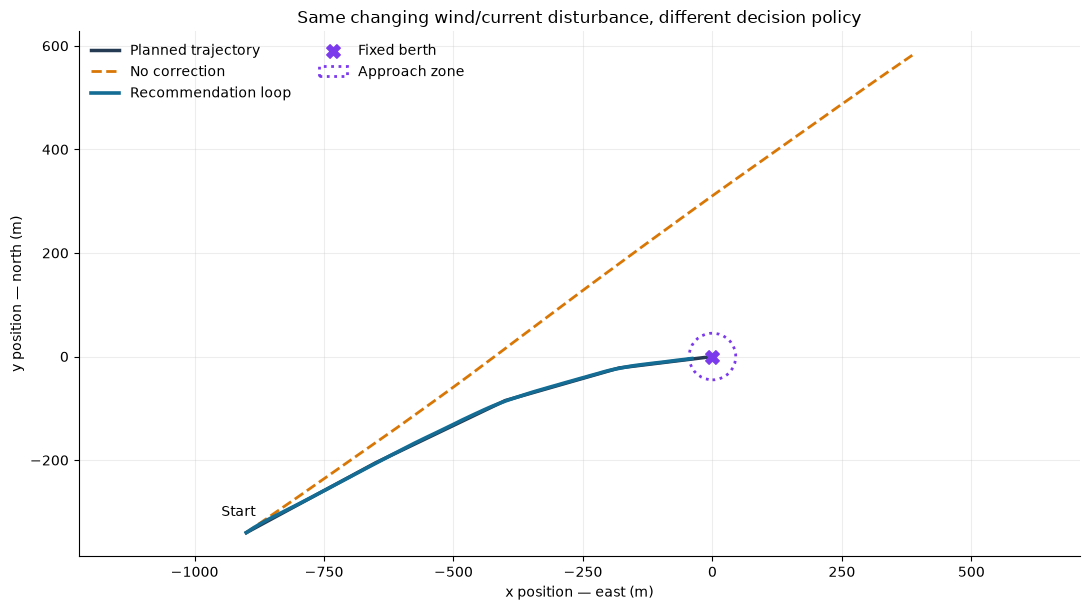

In [6]:
scenario = "changing_wind_current"
baseline_run = runs[(scenario, "No correction")]
closed_run = runs[(scenario, "Recommendation loop")]

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.plot(trajectory.x, trajectory.y, color=COLORS["plan"], lw=2.5, label="Planned trajectory")
ax.plot(baseline_run.x_position_m, baseline_run.y_position_m, "--", color=COLORS["baseline"], lw=2.0, label="No correction")
ax.plot(closed_run.x_position_m, closed_run.y_position_m, color=COLORS["loop"], lw=2.6, label="Recommendation loop")
ax.scatter([berth.target_x], [berth.target_y], s=95, marker="X", color=COLORS["berth"], label="Fixed berth", zorder=5)
ax.add_patch(Circle((berth.target_x, berth.target_y), berth.approach_zone_radius_m,
                    fill=False, ls=":", lw=2, color=COLORS["berth"], label="Approach zone"))
ax.annotate("Start", (trajectory.iloc[0].x, trajectory.iloc[0].y), xytext=(-18, 12), textcoords="offset points")
ax.set(title="Same changing wind/current disturbance, different decision policy",
       xlabel="x position — east (m)", ylabel="y position — north (m)")
ax.legend(frameon=False, ncol=2)
ax.set_aspect("equal", adjustable="datalim")
fig.tight_layout()
fig.savefig(ASSETS / "trajectory_tracking_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Cross-Track Error Over Time

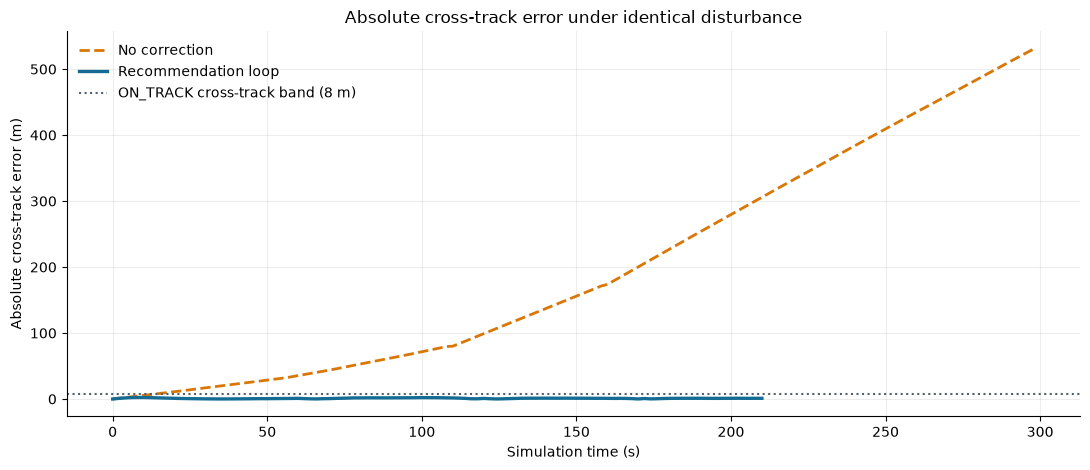

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(baseline_run.timestamp_s, baseline_run.cross_track_error_m.abs(), "--",
        color=COLORS["baseline"], lw=2, label="No correction")
ax.plot(closed_run.timestamp_s, closed_run.cross_track_error_m.abs(),
        color=COLORS["loop"], lw=2.4, label="Recommendation loop")
ax.axhline(8, color="#52606D", ls=":", label="ON_TRACK cross-track band (8 m)")
ax.set(title="Absolute cross-track error under identical disturbance",
       xlabel="Simulation time (s)", ylabel="Absolute cross-track error (m)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(ASSETS / "cross_track_error_over_time.png", dpi=170, bbox_inches="tight")
plt.show()

## 9. Performance and Scenario Comparison

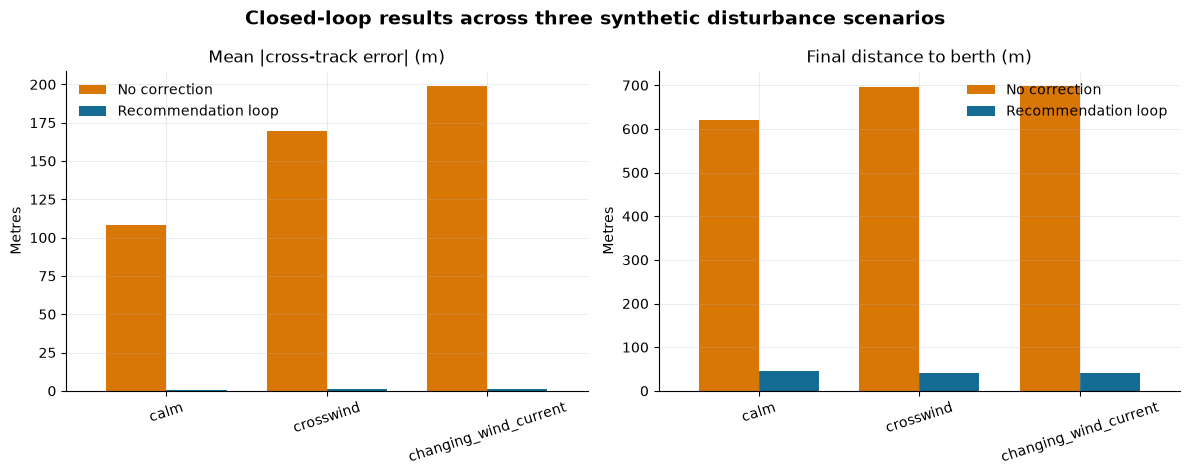

In [8]:
plot_metrics = metrics.copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for index, (measure, label) in enumerate([
    ("mean_cross_track_error_m", "Mean |cross-track error| (m)"),
    ("final_position_error_m", "Final distance to berth (m)"),
]):
    pivot = plot_metrics.pivot(index="scenario", columns="controller", values=measure).reindex(SCENARIOS)
    pivot.plot.bar(ax=axes[index], color=[COLORS["baseline"], COLORS["loop"]], width=0.75)
    axes[index].set(title=label, xlabel="", ylabel="Metres")
    axes[index].tick_params(axis="x", rotation=18)
    axes[index].legend(frameon=False, title="")
fig.suptitle("Closed-loop results across three synthetic disturbance scenarios", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(ASSETS / "scenario_comparison.png", dpi=170, bbox_inches="tight")
plt.show()

In [9]:
action_counts = pd.concat(
    [run.assign(run_scenario=scenario) for (scenario, controller), run in runs.items() if controller == "Recommendation loop"]
).groupby(["run_scenario", "recommended_action"]).size().unstack(fill_value=0)
display(action_counts)

recommended_action,CORRECT_STARBOARD,INCREASE_SPEED,MAINTAIN,REDUCE_SPEED,STABILIZE
run_scenario,,,,,
calm,17,0,67,0,46
changing_wind_current,20,1,73,4,8
crosswind,20,0,73,9,3


## 10. Human in the Loop

The output is **“Recommend CORRECT_PORT”**, not an autonomous command. A pilot or bridge operator may accept or override it. A production record would log the observed state, environment, predicted state, candidate scores, recommendation, reason, operator decision, model/simulator versions, and latency.

## 11. Failure Modes

| Failure mode | Why it matters | Example mitigation |
|---|---|---|
| State-estimation error | GPS/AIS/sensor error corrupts current state | Redundant sensors, plausibility checks |
| Environment error | Wind/current estimates are wrong | Uncertainty bounds, conservative fallback |
| Model error / shift | New vessel or conditions differ from training | Drift detection, simulation tests, versioning |
| Action-model error | Simplified dynamics mis-rank actions | Bounded actions, calibrated vessel model |
| Latency | Advice arrives too late | Latency SLOs, stale-recommendation rejection |
| Trajectory failure | The nominal plan is no longer appropriate | Pilot override and replanning workflow |

## 12. Production and Monitoring Considerations

- **Model:** next-position MAE/RMSE/p95 error and residual drift.
- **Trajectory:** cross-track error, heading error, and final approach-zone error.
- **System:** recommendation latency, availability, and failed predictions.
- **Operations:** correction frequency, override rate, on-track share, and time to zone.
- **Governance:** audit logs, versioned models, bounded actions, and simulation-based release gates.

Real operations remain governed by certified navigation systems, pilots, bridge crew, COLREG/port procedures, vessel-specific dynamics, redundant sensors, and safety systems.

## 13. Final Takeaways

In [10]:
focus = metrics[metrics.scenario.eq("changing_wind_current")].set_index("controller")
baseline = focus.loc["No correction"]
guided = focus.loc["Recommendation loop"]
display(Markdown(
    f"- In the changing wind/current case, mean absolute cross-track error fell from "
    f"**{baseline.mean_cross_track_error_m:.1f} m** to **{guided.mean_cross_track_error_m:.1f} m**.  \n"
    f"- The recommendation loop reached the 45 m approach zone in **{guided.time_to_approach_zone_s:.0f} s** "
    f"with **{guided.corrective_recommendations:.0f} corrective recommendations**; the maintain-only run did not reach it.  \n"
    "- These results validate the closed-loop story inside this synthetic simulator only. Human authority and production safety controls remain essential."
))

- In the changing wind/current case, mean absolute cross-track error fell from **198.9 m** to **1.0 m**.  
- The recommendation loop reached the 45 m approach zone in **210 s** with **33 corrective recommendations**; the maintain-only run did not reach it.  
- These results validate the closed-loop story inside this synthetic simulator only. Human authority and production safety controls remain essential.